In [25]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.optimizers import Adam

In [26]:
# load the dataset
df = pd.read_csv('monthly_milk_production.csv')

In [27]:
# display first few rows
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [28]:
# dataset info
df.info

<bound method DataFrame.info of         Date  Production
0    1962-01         589
1    1962-02         561
2    1962-03         640
3    1962-04         656
4    1962-05         727
..       ...         ...
163  1975-08         858
164  1975-09         817
165  1975-10         827
166  1975-11         797
167  1975-12         843

[168 rows x 2 columns]>

In [29]:
# rename columns if needed
df.columns = ['Month', 'Milk_Production']

In [30]:
# convert month to datetime
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)


#####  Exploratory Data Analysis (EDA)

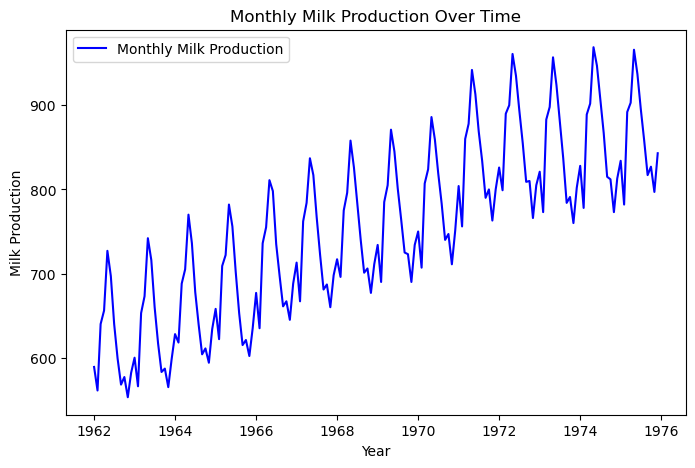

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(df['Milk_Production'], label='Monthly Milk Production', color='blue')
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Year')
plt.ylabel('Milk Production')
plt.legend()
plt.show()

In [32]:
# check for missing values
df.isnull().sum()

Milk_Production    0
dtype: int64

In [33]:
# check for duplicate values
df.duplicated().sum()

np.int64(26)

##### Data Normalization

In [34]:
scaler = MinMaxScaler()
scaled_df = scaler.fit_transform(df)

##### Prepare Time Series Data

In [35]:
def create_sequences(df, time_steps=12):
    X, y = [], []
    for i in range(len(df) - time_steps):
        X.append(df[i:i+time_steps])
        y.append(df[i+time_steps])
    return np.array(X), np.array(y)

TIME_STEPS = 12  # Using last 12 months to predict next month
X, y = create_sequences(scaled_df, TIME_STEPS)

In [36]:
# Train-Test Split (80-20)
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"\nTrain samples: {len(X_train)}, Test samples: {len(X_test)}")


Train samples: 124, Test samples: 32


##### Build Models

In [37]:
def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer=Adam(0.001), loss='mse')
    return model

##### Train Models

In [38]:
models = {
    "RNN": build_rnn((TIME_STEPS, 1)),
    "LSTM": build_lstm((TIME_STEPS, 1)),
    "GRU": build_gru((TIME_STEPS, 1))
}

history = {}

for name, model in models.items():
    print(f"\nTraining {name} model...")
    hist = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0, validation_split=0.1)
    history[name] = hist


Training RNN model...

Training LSTM model...

Training GRU model...


#####  Model Evaluation

In [39]:
results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_rescaled = scaler.inverse_transform(y_pred)
    y_test_rescaled = scaler.inverse_transform(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
    mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
    results[name] = {'RMSE': rmse, 'MAE': mae}

# Display Results
print("\nModel Performance:")
for name, metrics in results.items():
    print(f"{name} -> RMSE: {metrics['RMSE']:.2f}, MAE: {metrics['MAE']:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step

Model Performance:
RNN -> RMSE: 20.77, MAE: 15.69
LSTM -> RMSE: 38.36, MAE: 31.13
GRU -> RMSE: 32.33, MAE: 26.02


##### Visualization of Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


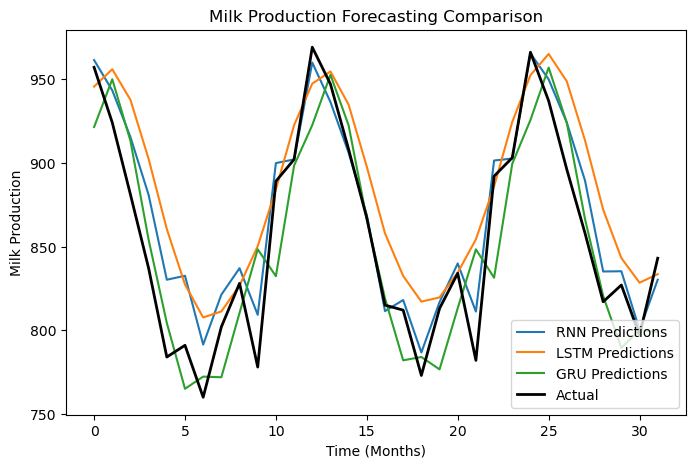

In [47]:
plt.figure(figsize=(8, 5))
for name, model in models.items():
    y_pred = model.predict(X_test)
    y_pred_rescaled = scaler.inverse_transform(y_pred)
    plt.plot(y_pred_rescaled, label=f'{name} Predictions')

plt.plot(scaler.inverse_transform(y_test), label='Actual', color='black', linewidth=2)
plt.title("Milk Production Forecasting Comparison")
plt.xlabel("Time (Months)")
plt.ylabel("Milk Production")
plt.legend()
plt.show()

##### Forecast Next 12 Months

In [41]:
last_sequence = scaled_df[-TIME_STEPS:]
future_predictions = []

model = models['LSTM']  # Use best-performing model
for _ in range(12):
    pred = model.predict(last_sequence.reshape(1, TIME_STEPS, 1))
    future_predictions.append(pred[0, 0])
    last_sequence = np.append(last_sequence[1:], pred, axis=0)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


In [44]:
# Inverse transform
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

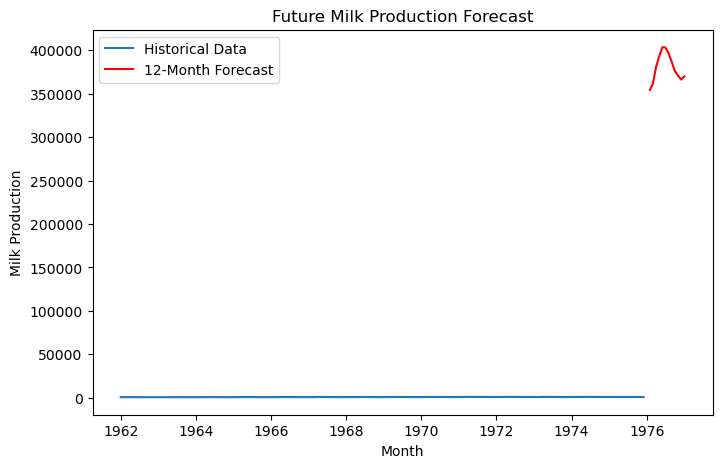

In [46]:
# Plot Forecast
plt.figure(figsize=(8, 5))
plt.plot(df.index, df['Milk_Production'], label='Historical Data')
future_dates = pd.date_range(df.index[-1], periods=13, freq='M')[1:]
plt.plot(future_dates, future_predictions, label='12-Month Forecast', color='red')
plt.title('Future Milk Production Forecast')
plt.xlabel('Month')
plt.ylabel('Milk Production')
plt.legend()
plt.show()

                                                  Submitted by: Meghana C Varghese